In [3]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Downloads and unzips wine data through UCI Database
!curl -O https://archive.ics.uci.edu/static/public/186/wine+quality.zip
!unzip wine+quality.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 91353    0 91353    0     0   402k      0 --:--:-- --:--:-- --:--:--  401k
Archive:  wine+quality.zip
  inflating: winequality-red.csv     
  inflating: winequality-white.csv   
  inflating: winequality.names       


In [5]:
# use pandas to read the CSV file
red_wine_df = pd.read_csv("winequality-red.csv", sep=';')
red_wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
# Extract features
features = red_wine_df.iloc[:, :11]

In [7]:
# Calculate standard deviation for each feature
std_dev = red_wine_df.std()
print(std_dev)

fixed acidity            1.741096
volatile acidity         0.179060
citric acid              0.194801
residual sugar           1.409928
chlorides                0.047065
free sulfur dioxide     10.460157
total sulfur dioxide    32.895324
density                  0.001887
pH                       0.154386
sulphates                0.169507
alcohol                  1.065668
quality                  0.807569
dtype: float64


In [8]:
# Calculate maximum values for each feature
max_values = red_wine_df.max()
print(max_values)

fixed acidity            15.90000
volatile acidity          1.58000
citric acid               1.00000
residual sugar           15.50000
chlorides                 0.61100
free sulfur dioxide      72.00000
total sulfur dioxide    289.00000
density                   1.00369
pH                        4.01000
sulphates                 2.00000
alcohol                  14.90000
quality                   8.00000
dtype: float64


In [10]:
# Scale the feature values
scaled_df = features / max_values
scaled_df.head()

,alcohol,chlorides,citric acid,density,fixed acidity,free sulfur dioxide,pH,quality,residual sugar,sulphates,total sulfur dioxide,volatile acidity
0,0.630872,0.124386,0.00,0.994132,0.465409,0.152778,0.875312,NaN,0.122581,0.280,0.117647,0.443038
1,0.657718,0.160393,0.00,0.993135,0.490566,0.347222,0.798005,NaN,0.167742,0.340,0.231834,0.556962
2,0.657718,0.150573,0.04,0.993335,0.490566,0.208333,0.812968,NaN,0.148387,0.325,0.186851,0.481013
3,0.657718,0.122750,0.56,0.994331,0.704403,0.236111,0.788030,NaN,0.122581,0.290,0.207612,0.177215
4,0.630872,0.124386,0.00,0.994132,0.465409,0.152778,0.875312,NaN,0.122581,0.280,0.117647,0.443038


In [ ]:
# Save the stdev to a text file
std_dev_strs = [str(val) for val in std_dev]
std_dev_result = ", ".join(std_dev_strs)
with open("std_devs.txt", 'w') as f:
    f.write(std_dev_result)

In [ ]:
# Save the scaled features to a text file
with open("scaled_features.txt", 'w') as f:
    for index, row in scaled_df.iterrows():
        feature_string = ", ".join([str(val) for val in row])
        f.write(feature_string)
        f.write("\n")

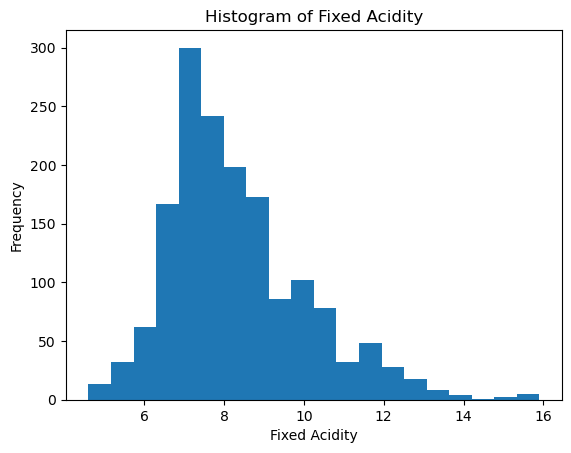

In [13]:
# Plot histogram of fixed acidity
plt.hist(features["fixed acidity"], bins=20)
plt.xlabel('Fixed Acidity')
plt.ylabel('Frequency')
plt.title('Histogram of Fixed Acidity')
# Save the plot to a file
plt.savefig('fixed_acidity_histogram.png')
plt.show()

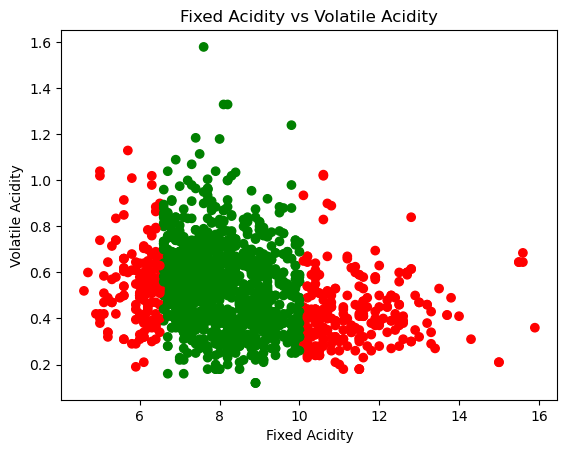

In [ ]:
# Plot fixed acidity (index 0) vs volatile acidity (index 1) with color coding based on fixed acidity standard deviation
mean_fixed_acidity = features["fixed acidity"].mean()
std_fixed_acidity = features["fixed acidity"].std()

fixed_acidity = features["fixed acidity"]
diff_fix_acidity = fixed_acidity - mean_fixed_acidity
abs_diff_fix_acidity = abs(diff_fix_acidity)
colors = ['red' if x > std_fixed_acidity else 'green' for x in abs_diff_fix_acidity]

plt.scatter(features["fixed acidity"], features["volatile acidity"], c=colors)
plt.xlabel('Fixed Acidity')
plt.ylabel('Volatile Acidity')
plt.title('Fixed Acidity vs Volatile Acidity')

# Write the plot to a file
plt.savefig('wine.png')

plt.show()